# Feature Manipulation in Pandas

Here let's look at a different dataset that will allow us to really dive into some meaningful visualizations. This data set is publically available, but it is also part of a Kaggle competition.

You can get the data from here: https://www.kaggle.com/c/titanic-gettingStarted or you can use the code below to load the data from GitHub.

There are lots of iPython notebooks for looking at the Titanic data. Check them out and see if you like any better than this one!

When going through visualization options, I recommend the following steps:
- Would you like the visual to be interactive?
  - Yes, Does it have a lot of data?
    - No, Use plotly or bokeh
    - Yes, sub-sample and then use plotly/bokeh
    - Yes, think about using Turi for large data
  - No, Does seaborn have a built-in function for plotting?
    - Yes, use seaborn
    - No, Does Pandas support the visual?
      - Yes, use pandas
      - No, use low level matplotlib
      
Look at various high level plotting libraries like:
- Altair (https://altair-viz.github.io)
- Bokeh (http://bokeh.pydata.org/en/latest/)
- And many others...

## Adding Dependencies (for Jupyter Lab)
- `conda install -c conda-forge missingno`
- `conda install nodejs`
- `jupyter labextension install @jupyterlab/plotly-extension`

# Loading the Titanic Data for Example Visualizations

In [8]:
# load the Titanic dataset
import pandas as pd
import numpy as np

print('Pandas:', pd.__version__)
print('Numpy:',np.__version__)

#df = pd.read_csv('https://raw.githubusercontent.com/eclarson/DataMiningNotebooks/master/data/titanic.csv') # read in the csv file

#df.head()

#df = pd.read_json('https://paleobiodb.org/data1.2/occs/list.json?lngmin=-105.4688&lngmax=-92.8564&latmin=24.5271&latmax=38.7369&base_id=52775&show=coords,attr,loc,prot,time,strat,stratext,lith,lithext,geo,rem,ent,entname,crmod&datainfo')
#df.head()

df = pd.read_csv("./pbdb_data-no-metadata.csv")
df.head()

Pandas: 2.3.2
Numpy: 2.3.2


,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,...,modifier,updater,created,modified,updated,paleomodel,geoplate,paleoage,paleolng,paleolat
0,139341,occ,13412.0,NaN,11932,Pleurocoelus sp.,genus,54170,NaN,Titanosauriformes,...,M. Carrano,NaN,2005-08-25 14:56:00,2005-08-25 16:56:00,NaN,gplates,101,mid,-39.65,37.81
1,220148,occ,NaN,NaN,22709,Theropoda indet.,unranked clade,38513,NaN,Theropoda,...,M. Carrano,NaN,2002-07-10 20:49:32,2013-10-25 16:23:05,NaN,gplates,101,mid,-68.74,38.52
2,220149,occ,40298.0,NaN,22709,Saurolophinae indet.,subfamily,53385,NaN,Saurolophinae,...,NaN,NaN,2022-12-02 16:38:06,2022-12-02 16:38:06,NaN,gplates,101,mid,-68.74,38.52
3,220150,occ,NaN,NaN,22709,Carnosauria indet.,infraorder,53943,NaN,Carnosauria,...,M. Carrano,NaN,2002-07-10 20:49:32,2013-10-25 16:23:05,NaN,gplates,101,mid,-68.74,38.52
4,220190,occ,35569.0,NaN,22713,Convolosaurus marri n. gen. n. sp.,species,382687,NaN,Convolosaurus marri,...,NaN,NaN,2019-03-13 10:22:26,2019-03-13 10:22:26,NaN,gplates,101,mid,-41.71,35.74


In [9]:
# note that the describe function defaults to using only some variables
df.describe()

,occurrence_no,reid_no,collection_no,identified_no,accepted_attr,accepted_no,max_ma,min_ma,reference_no,lng,...,regionalbedunit,regionalorder,authorizer_no,enterer_no,modifier_no,updater_no,updater,updated,paleolng,paleolat
count,1.179000e+03,222.000000,1179.000000,1179.000000,0.0,1179.000000,1179.000000,1179.000000,1179.000000,1179.000000,...,0.0,0.0,1179.000000,1179.000000,1179.000000,0.0,0.0,0.0,1080.000000,1080.000000
mean,9.837003e+05,31163.909910,100824.396947,82651.236641,NaN,69623.966073,100.072554,89.908984,44771.240882,-102.210237,...,NaN,NaN,54.431722,82.083121,41.211196,NaN,NaN,NaN,-58.682954,34.061889
std,4.648948e+05,9695.916871,69245.050679,84005.921026,NaN,73224.877284,53.405098,49.739945,28991.261150,3.020217,...,NaN,NaN,143.434767,157.989898,116.209117,NaN,NaN,NaN,14.971638,9.134804
min,1.393410e+05,12534.000000,3534.000000,36616.000000,NaN,36616.000000,0.011700,0.000000,312.000000,-107.462601,...,NaN,NaN,4.000000,4.000000,0.000000,NaN,NaN,NaN,-104.540000,6.630000
25%,5.339625e+05,20944.250000,52168.000000,38713.000000,NaN,38653.000000,83.600000,72.200000,15506.000000,-103.637131,...,NaN,NaN,14.000000,14.000000,0.000000,NaN,NaN,NaN,-69.010000,34.570000
50%,8.414080e+05,34398.500000,70030.000000,53382.000000,NaN,38851.000000,83.600000,72.200000,46717.000000,-103.159576,...,NaN,NaN,14.000000,14.000000,14.000000,NaN,NaN,NaN,-68.140000,38.020000
75%,1.436370e+06,40052.750000,170942.000000,91968.000000,NaN,64079.000000,113.200000,110.100000,69370.000000,-101.162639,...,NaN,NaN,14.000000,14.000000,14.000000,NaN,NaN,NaN,-45.347500,38.700000
max,1.706328e+06,42528.000000,236775.000000,502841.000000,NaN,502841.000000,237.000000,227.300000,327912.000000,-91.976028,...,NaN,NaN,969.000000,1101.000000,969.000000,NaN,NaN,NaN,-30.170000,49.210000


In [10]:
print(df.dtypes)
print('===========')
print(df.info())

occurrence_no      int64
record_type       object
reid_no          float64
flags             object
collection_no      int64
                  ...   
paleomodel        object
geoplate          object
paleoage          object
paleolng         float64
paleolat         float64
Length: 91, dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1179 entries, 0 to 1178
Data columns (total 91 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   occurrence_no        1179 non-null   int64  
 1   record_type          1179 non-null   object 
 2   reid_no              222 non-null    float64
 3   flags                101 non-null    object 
 4   collection_no        1179 non-null   int64  
 5   identified_name      1179 non-null   object 
 6   identified_rank      1179 non-null   object 
 7   identified_no        1179 non-null   int64  
 8   difference           41 non-null     object 
 9   accepted_name        1179 non-null   

## Questions we might want to ask:
- What percentage of passengers survived the Titanic disaster?
- What percentage survived in each class (first, coach, etc.)?
- How many people traveled in each class? How many classes are there?



In [11]:
# the percentage of individuals that survived on the titanic
#num_survived = sum(df.Survived == 1)
#print(num_survived, "survivors")
#print(num_survived/len(df)*100.0, "%")

## Grouping the Data

In [12]:
# Lets aggregate by class and count survival rates
#df_grouped = df.groupby(by='Pclass')

#for val,grp in df_grouped:
#    print(f'There were {len(grp)} people traveling in {val} class.')

In [13]:
# an example of using the groupby function with a data column
#print(df_grouped['Survived'].sum())
#print('---------------------------------------')
#print(df_grouped.Survived.count())
#print('---------------------------------------')
#print(df_grouped.Survived.sum() / df_grouped.Survived.count())

# might there be a better way of displaying this data?

___________
# Cleaning the Dataset
Let's start by visualizing some of the missing data in this dataset. We will use the `missingno` package to help visualize where the data contains `NaNs`. This is a great tool for looking at nan values and how we might go about filling in the values. 

For this visualization, we can use a visualization library called `missingno` that hs many types of visuals for looking at missing data in a dataframe. I particularly like the `matrix` visualization, but there are many more to explore:
- https://github.com/ResidentMario/missingno

### Plot Type One: Filter Bar

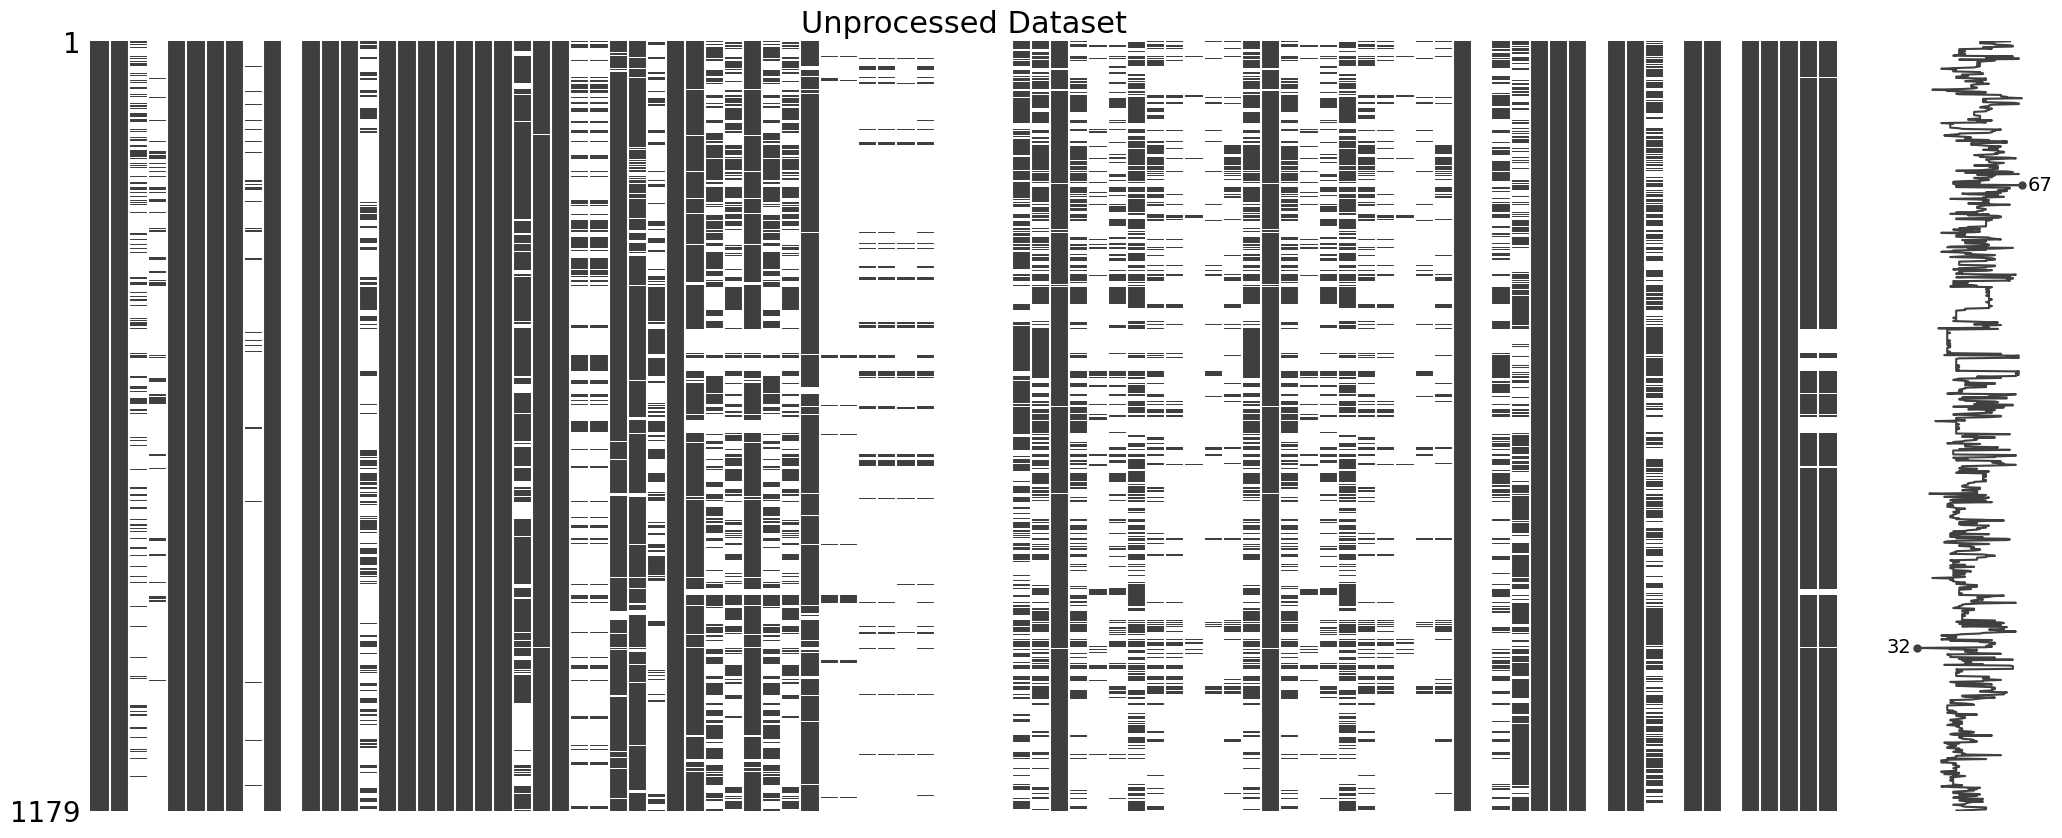

<Figure size 640x480 with 0 Axes>

In [14]:
# this python magics will allow plot to be embedded into the notebook
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('ignore', DeprecationWarning)
%matplotlib inline 

# External package: conda install missingno 
import missingno as mn

mn.matrix(df)
plt.title("Unprocessed Dataset",fontsize=22)

plt.figure()
plt.show()

Let's clean the dataset a little before moving on

1. Remove attributes that just aren't useful for us

* PassengerID is simply an identifier and not useful for analysis
* Ticket is simply an identifier and not useful for analysis
* Cabin is largely not present so not useful for analysis
* Name would be very difficult to analyze without prior processing

Dropped columns with no values: ['accepted_attr', 'regionalsection', 'regionalbed', 'regionalbedunit', 'regionalorder', 'updater_no', 'updater', 'updated']
Dropped duplicate columns: ['lithification1.1', 'fossilsfrom1.1', 'lithadj2.1', 'lithology2.1', 'fossilsfrom2.1', 'formation.1', 'minor_lithology2.1', 'minor_lithology1.1', 'geological_group.1', 'lithadj1.1', 'lithification2.1', 'member.1', 'lithology1.1', 'lithdescript.1']
Dropped columns with at least 80% not available: ['reid_no', 'flags', 'difference', 'zone', 'zone_type', 'localsection', 'localbed', 'localbedunit', 'localorder', 'lithification1', 'lithadj2', 'lithification2', 'minor_lithology2', 'fossilsfrom2', 'tectonic_setting']
Dropped columns with only 1 unique value: ['record_type', 'paleomodel', 'paleoage']
Manually selected columns to drop: ['occurrence_no', 'collection_no', 'identified_no', 'cx_int_no', 'accepted_no', 'reference_no', 'authorizer_no', 'enterer_no', 'modifier_no', 'authorizer', 'enterer', 'modifier', 'cre

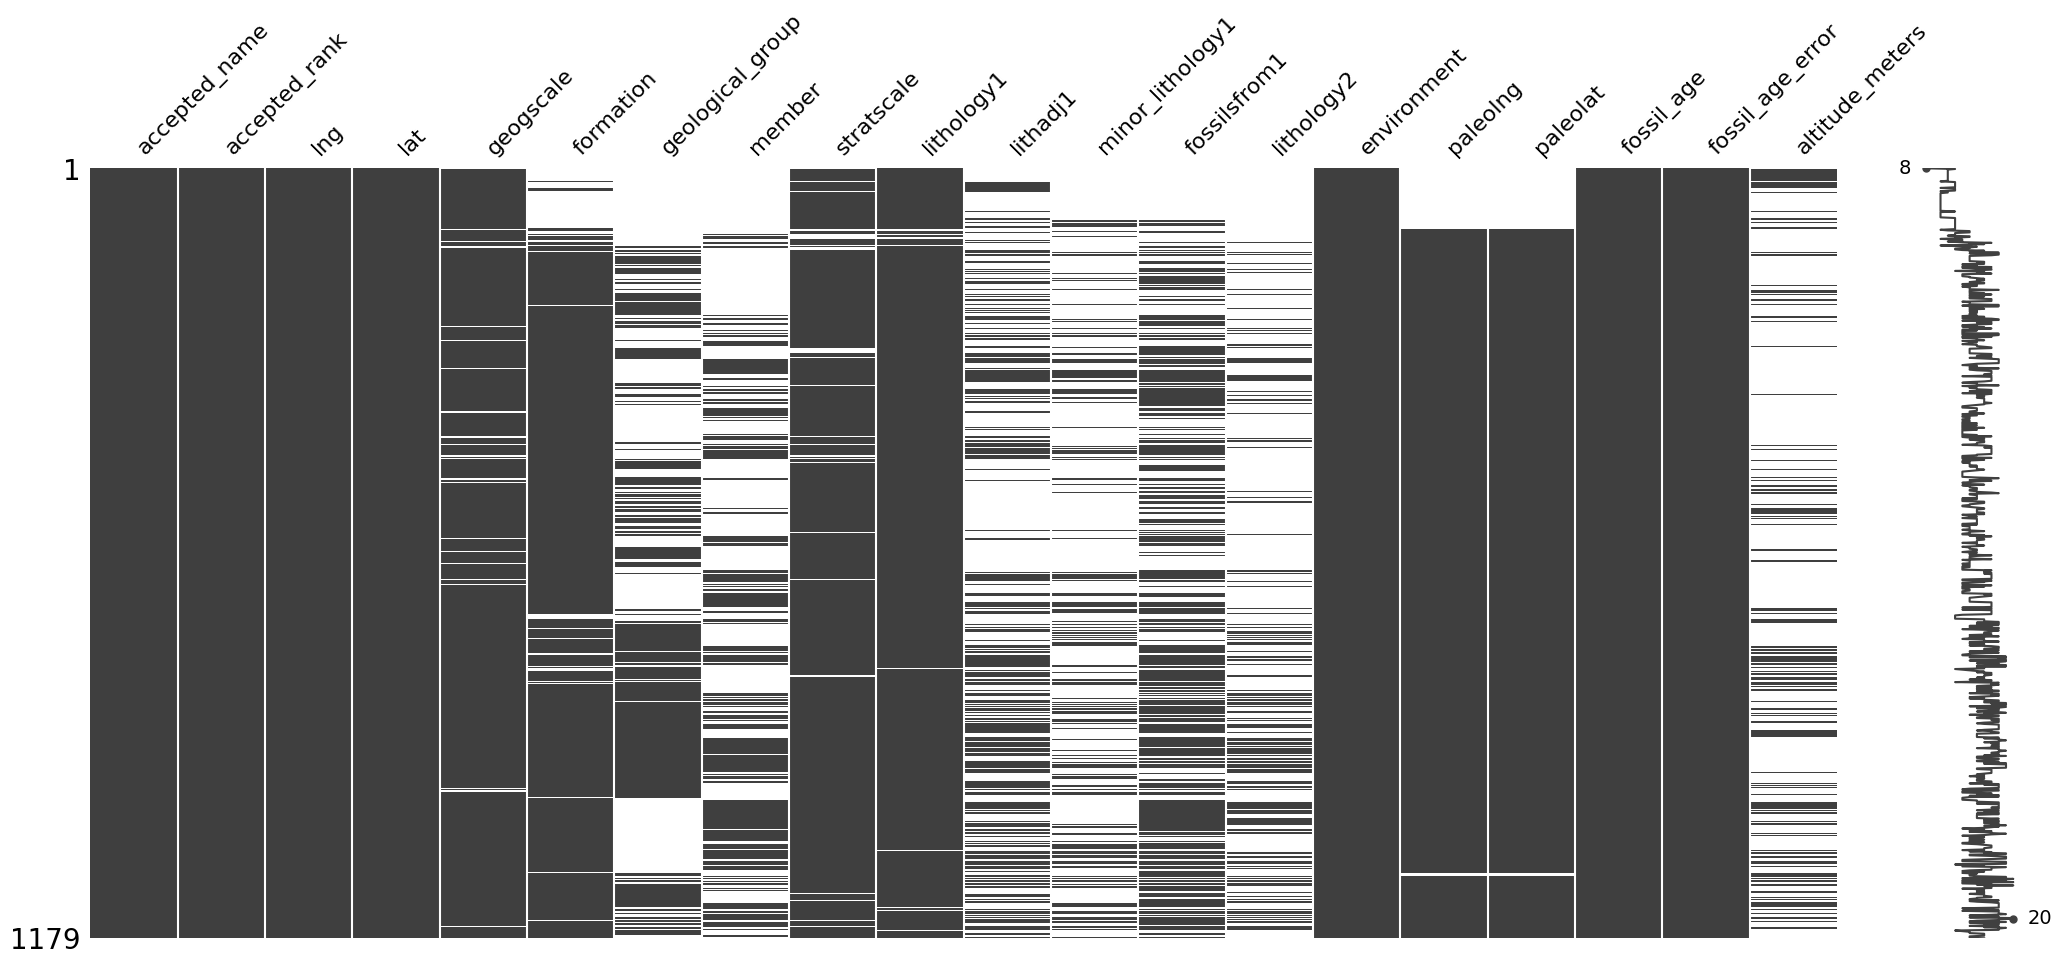

<Axes: ylabel='Frequency'>

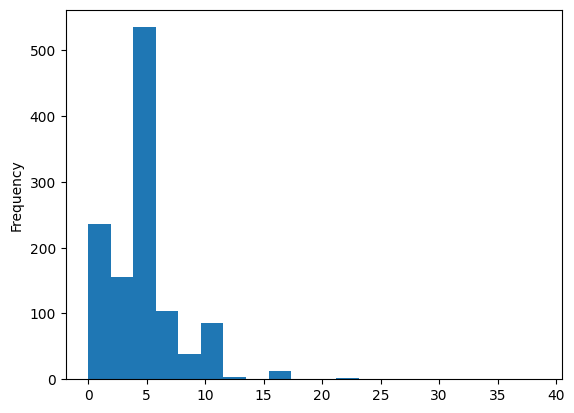

In [15]:
def getCol(df, index): return df.iloc[:, index]
def getColName(df, index): return df.columns.values[index]
def getNumRows(df): return df.shape[0]
def getNumCols(df): return df.shape[1]
def getDuplicateCols(df):
    ret = set()
    numCols = getNumCols(df)
    for i in range(numCols):
        col = getCol(df, i)
        for j in range(i + 1, numCols):
            otherCol = getCol(df, j)
            if col.equals(otherCol):
                colName = getColName(df, i)
                otherColName = getColName(df, j)
                #print("Found duplicate pair:", colName, otherColName)
                ret.add(otherColName)
    return list(ret)

def getMissingCols(df, proportion):
    return [col for col in df.columns if df[col].count() <= (proportion * getNumRows(df))]
    
def uniqueCols(df, maxUniqueVals):
    return [col for col in df.columns if len(df[col].unique()) <= maxUniqueVals]

if getNumCols(df) < 91:
    print("We dropped columns already")
else:
    nullCols = getMissingCols(df, 0)
    print("Dropped columns with no values:", nullCols)
    df.drop(columns=nullCols, inplace=True)

    duplicates = getDuplicateCols(df)
    print("Dropped duplicate columns:", duplicates)
    df.drop(columns=duplicates, inplace=True)

    missingCols = getMissingCols(df, 0.20)
    print("Dropped columns with at least 80% not available:", missingCols)
    df.drop(columns=missingCols, inplace=True)

    uniques = uniqueCols(df, 1)
    print("Dropped columns with only 1 unique value:", uniques)
    df.drop(columns=uniques, inplace=True)

    manual_drop = [
        # Identifiers only
        'occurrence_no', 'collection_no', 'identified_no', 'cx_int_no',
        'accepted_no', 'reference_no', 'authorizer_no', 'enterer_no', 'modifier_no',
        'authorizer', 'enterer', 'modifier', 'created', 'modified',
        # Cannot be analyzed for our purposes
        'geogcomments', 'stratcomments', 'geology_comments', 'occurrence_comments',
        'lithdescript', 'protected', 'geoplate',
        # These fields were better represented by another field
        'early_interval', 'late_interval', 'latlng_basis', 'latlng_precision',
        'identified_name', 'identified_rank', 'cc', 'state', 'county'
        ]
    print("Manually selected columns to drop:", manual_drop)
    df.drop(columns=manual_drop, inplace=True)

    # Normalization
    df['fossil_age'] = (df['max_ma'] + df['min_ma']) / 2
    df['fossil_age_error'] = (df['max_ma'] - df['min_ma']) / 2
    df.drop(columns=['min_ma', 'max_ma'], inplace=True)
    
    df['altitude_meters'] = np.where(df['altitude_unit'] == 'feet',
        0.3048 * df['altitude_value'], df['altitude_value'])
    df.drop(columns=['altitude_value', 'altitude_unit'], inplace=True)

    # 

df.info()

mn.matrix(df.sort_values(by = ['fossil_age']))
plt.show()
df['fossil_age_error'].plot.hist(bins=20)